# Laptop Price Prediction using Vanilla RNN
This notebook implements a vanilla Recurrent Neural Network (RNN) to predict laptop prices based on various features.

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tqdm import tqdm

## 1. Load and Explore Data

In [2]:
# Load the dataset
df = pd.read_csv('laptop_price.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nDataset info:")
print(df.info())
print(f"\nStatistical summary:")
print(df.describe())

Dataset shape: (1000, 7)

First few rows:
    Brand  Processor_Speed  RAM_Size  Storage_Capacity  Screen_Size    Weight  \
0    Asus         3.830296        16               512    11.185147  2.641094   
1    Acer         2.912833         4              1000    11.311372  3.260012   
2  Lenovo         3.241627         4               256    11.853023  2.029061   
3    Acer         3.806248        16               512    12.280360  4.573865   
4    Acer         3.268097        32              1000    14.990877  4.193472   

          Price  
0  17395.093065  
1  31607.605919  
2   9291.023542  
3  17436.728334  
4  32917.990718  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             1000 non-null   object 
 1   Processor_Speed   1000 non-null   float64
 2   RAM_Size          1000 non-null   int64  
 3   Sto

## 2. Data Preprocessing

In [3]:
# Encode categorical variable (Brand)
label_encoder = LabelEncoder()
df['Brand_Encoded'] = label_encoder.fit_transform(df['Brand'])

# Select features for the model
feature_columns = ['Brand_Encoded', 'Processor_Speed', 'RAM_Size', 
                   'Storage_Capacity', 'Screen_Size', 'Weight']
target_column = 'Price'

X = df[feature_columns].values
y = df[target_column].values.reshape(-1, 1)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (1000, 6)
Target shape: (1000, 1)


In [4]:
# Split the data
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 700 samples
Validation set: 150 samples
Test set: 150 samples


In [5]:
# Normalize features and target
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_val_scaled = scaler_y.transform(y_val)
y_test_scaled = scaler_y.transform(y_test)

## 3. Create Dataset and DataLoader

In [6]:
class LaptopDataset(Dataset):
    """Custom Dataset for laptop price prediction."""
    
    def __init__(self, X, y, seq_length=1):
        """
        Args:
            X: Feature array
            y: Target array
            seq_length: Sequence length for RNN (default=1 for treating each sample independently)
        """
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
        self.seq_length = seq_length
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        # Reshape to (seq_length, features) for RNN
        # Here we use seq_length=1, treating each sample as a single time step
        return self.X[idx].unsqueeze(0), self.y[idx]

# Create datasets
train_dataset = LaptopDataset(X_train_scaled, y_train_scaled)
val_dataset = LaptopDataset(X_val_scaled, y_val_scaled)
test_dataset = LaptopDataset(X_test_scaled, y_test_scaled)

# Create dataloaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of batches - Train: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")

Number of batches - Train: 22, Val: 5, Test: 5


## 4. Define Vanilla RNN Model

In [7]:
class VanillaRNN(nn.Module):
    """Vanilla RNN for laptop price prediction."""
    
    def __init__(self, input_size, hidden_size, num_layers, output_size, dropout=0.2):
        """
        Args:
            input_size: Number of input features
            hidden_size: Number of hidden units in RNN
            num_layers: Number of RNN layers
            output_size: Number of output values (1 for price prediction)
            dropout: Dropout rate for regularization
        """
        super(VanillaRNN, self).__init__()
        
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # Vanilla RNN layer
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            nonlinearity='tanh'
        )
        
        # Dropout layer
        self.dropout = nn.Dropout(dropout)
        
        # Fully connected output layer
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        """
        Forward pass.
        Args:
            x: Input tensor of shape (batch_size, seq_length, input_size)
        Returns:
            Output tensor of shape (batch_size, output_size)
        """
        # Initialize hidden state
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # Forward propagate RNN
        # out shape: (batch_size, seq_length, hidden_size)
        # h_n shape: (num_layers, batch_size, hidden_size)
        out, h_n = self.rnn(x, h0)
        
        # Take the output from the last time step
        out = out[:, -1, :]
        
        # Apply dropout
        out = self.dropout(out)
        
        # Pass through fully connected layer
        out = self.fc(out)
        
        return out

## 5. Model Configuration and Training Setup

In [8]:
# Model hyperparameters
input_size = X_train.shape[1]  # Number of features
hidden_size = 64  # Number of hidden units
num_layers = 2  # Number of RNN layers
output_size = 1  # Price prediction
dropout = 0.2  # Dropout rate
learning_rate = 0.001
num_epochs = 100

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Initialize model
model = VanillaRNN(input_size, hidden_size, num_layers, output_size, dropout).to(device)
print(f"\nModel Architecture:")
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Using device: cuda

Model Architecture:
VanillaRNN(
  (rnn): RNN(6, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Total parameters: 12,993
Trainable parameters: 12,993


In [10]:
# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10
)

## 6. Training Functions

In [11]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    
    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        # Forward pass
        predictions = model(X_batch)
        loss = criterion(predictions, y_batch)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping to prevent exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)

def validate(model, dataloader, criterion, device):
    """Validate the model."""
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)
            total_loss += loss.item()
    
    return total_loss / len(dataloader)

## 7. Train the Model

In [12]:
# Training loop
train_losses = []
val_losses = []
best_val_loss = float('inf')

print("Starting training...\n")

for epoch in range(num_epochs):
    # Train
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    
    # Validate
    val_loss = validate(model, val_loader, criterion, device)
    val_losses.append(val_loss)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_rnn_model.pth')
    
    # Print progress
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], "
              f"Train Loss: {train_loss:.4f}, "
              f"Val Loss: {val_loss:.4f}")

print("\nTraining completed!")
print(f"Best validation loss: {best_val_loss:.4f}")

Starting training...

Epoch [10/100], Train Loss: 0.0198, Val Loss: 0.0018
Epoch [20/100], Train Loss: 0.0143, Val Loss: 0.0008
Epoch [30/100], Train Loss: 0.0107, Val Loss: 0.0010
Epoch [40/100], Train Loss: 0.0102, Val Loss: 0.0007
Epoch [50/100], Train Loss: 0.0098, Val Loss: 0.0008
Epoch [60/100], Train Loss: 0.0091, Val Loss: 0.0006
Epoch [70/100], Train Loss: 0.0087, Val Loss: 0.0005
Epoch [80/100], Train Loss: 0.0088, Val Loss: 0.0006
Epoch [90/100], Train Loss: 0.0077, Val Loss: 0.0005
Epoch [100/100], Train Loss: 0.0089, Val Loss: 0.0005

Training completed!
Best validation loss: 0.0005


## 8. Plot Training History

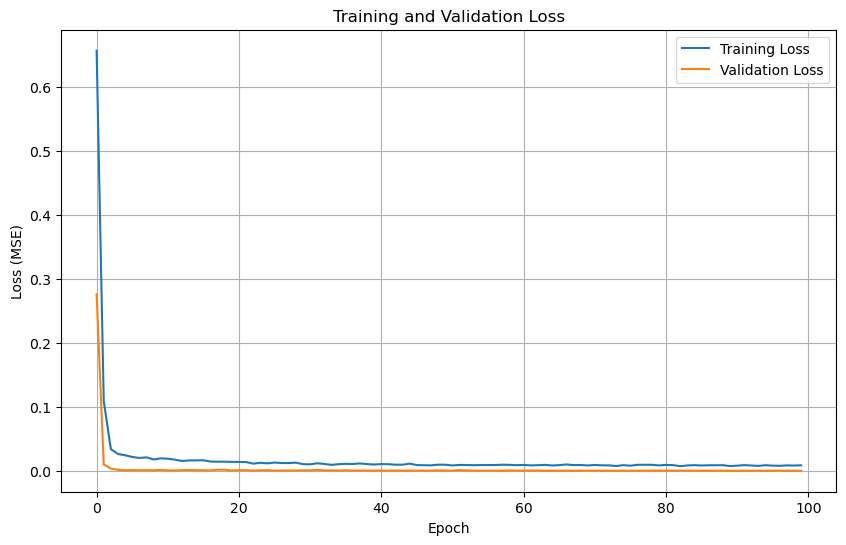

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

## 9. Evaluate on Test Set

In [15]:
# Load best model
model.load_state_dict(torch.load('best_rnn_model.pth'))

# Evaluate on test set
test_loss = validate(model, test_loader, criterion, device)
print(f"Test Loss (MSE): {test_loss:.4f}")

# Get predictions
model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        pred = model(X_batch)
        predictions.extend(pred.cpu().numpy())
        actuals.extend(y_batch.numpy())

predictions = np.array(predictions)
actuals = np.array(actuals)

# Inverse transform to get actual prices
predictions_actual = scaler_y.inverse_transform(predictions)
actuals_actual = scaler_y.inverse_transform(actuals)

# Calculate metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(actuals_actual, predictions_actual)
rmse = np.sqrt(mean_squared_error(actuals_actual, predictions_actual))
r2 = r2_score(actuals_actual, predictions_actual)

print(f"\nTest Set Performance:")
print(f"MAE: ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Test Loss (MSE): 0.0005

Test Set Performance:
MAE: $161.57
RMSE: $205.99
R² Score: 0.9996


## 10. Visualize Predictions

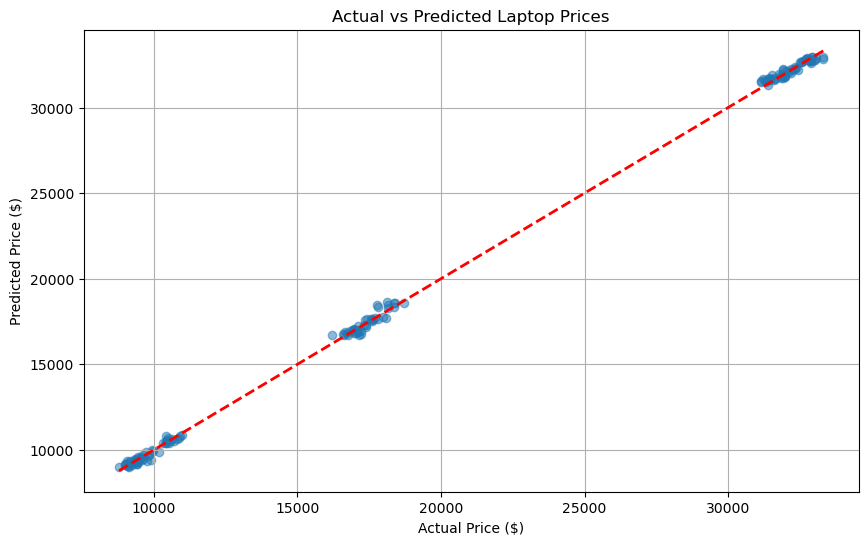

In [16]:
# Scatter plot: Actual vs Predicted
plt.figure(figsize=(10, 6))
plt.scatter(actuals_actual, predictions_actual, alpha=0.5)
plt.plot([actuals_actual.min(), actuals_actual.max()], 
         [actuals_actual.min(), actuals_actual.max()], 
         'r--', lw=2)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title('Actual vs Predicted Laptop Prices')
plt.grid(True)
plt.show()

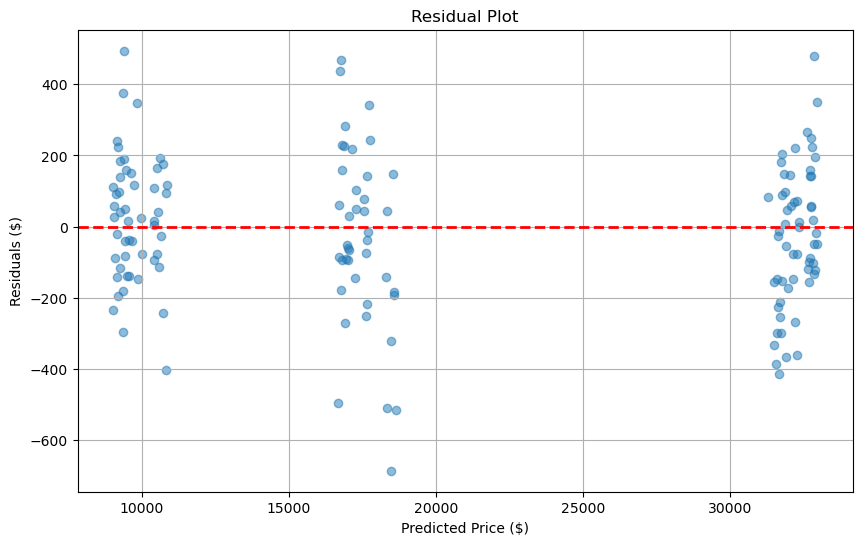

In [17]:
# Residual plot
residuals = actuals_actual - predictions_actual

plt.figure(figsize=(10, 6))
plt.scatter(predictions_actual, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Price ($)')
plt.ylabel('Residuals ($)')
plt.title('Residual Plot')
plt.grid(True)
plt.show()

## 11. Sample Predictions

In [18]:
# Show some sample predictions
sample_size = 10
sample_indices = np.random.choice(len(predictions_actual), sample_size, replace=False)

print("\nSample Predictions:")
print(f"{'Actual Price':<15} {'Predicted Price':<17} {'Difference':<15}")
print("-" * 50)

for idx in sample_indices:
    actual = actuals_actual[idx][0]
    predicted = predictions_actual[idx][0]
    diff = actual - predicted
    print(f"${actual:>13.2f}   ${predicted:>13.2f}   ${diff:>13.2f}")


Sample Predictions:
Actual Price    Predicted Price   Difference     
--------------------------------------------------
$     10438.45   $     10422.04   $        16.41
$     18371.27   $     18562.89   $      -191.62
$     10428.79   $     10505.44   $       -76.66
$     31641.11   $     31653.29   $       -12.18
$     32806.59   $     32752.40   $        54.19
$      9437.65   $      9577.07   $      -139.42
$      9105.36   $      9047.79   $        57.57
$     33063.24   $     32866.55   $       196.69
$     18071.46   $     17730.30   $       341.15
$      9123.79   $      9011.87   $       111.92
